In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

from utils_jax import *
dq.set_device('cpu')
import optax

# Get some initial params

In [2]:
EJ = 3
EC = 3/3
EL = 3/30

n_lvls_transmon  = 4
n_lvls_fluxonium = 20

qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": EJ, "Ec": EC, "El": EL, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )

In [3]:
def detuned_rabi_period(amp_with_2pi, element, detunning):
    # element: obtained from scqubit operator
    # detunning: obtained from scqubit
    return 2*jnp.pi / jnp.sqrt(
        (amp_with_2pi*element)**2
        + (2*jnp.pi*detunning)**2
    )

In [5]:
def objective(params):    
    one_period_mult = 0.5
    zero_period_mult = 3
    two_period_mult = 3

    Ej_t, g_tf, amp_with_2pi = params
    

    qst = MyTransmon.create(
        N = n_lvls_transmon,
        params = {"Ej": Ej_t, "Ec": 0.2,"ng":0.0},
        N_max_charge=10
        )

    devices = [qsf, qst]
    f_indx = 0
    t_indx = 1
    Ns = [device.N for device in devices]
    fn = qs.promote(qsf.ops["n"], f_indx, Ns)
    tn = qs.promote(qst.ops['n'], t_indx, Ns)

    system = qs.System.create(devices, couplings=[
        g_tf *  fn @ tn
        ])
    system.params["g_tf"] = g_tf
    system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
    system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
    driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)

    def get_dressed_idx(ql,tl):
        return find_closest_dressed_index(ql*qst.N+tl, product_indices_sorted_by_eval)
    zero = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]
    one = system_evals_in_product_indices[1,1] - system_evals_in_product_indices[1,0]
    two = system_evals_in_product_indices[2,1] - system_evals_in_product_indices[2,0]
    zero_period = detuned_rabi_period(amp_with_2pi, jnp.abs(driven_op[get_dressed_idx(0,0),get_dressed_idx(0,1)]),one -zero)
    one_period = detuned_rabi_period(amp_with_2pi, jnp.abs(driven_op[get_dressed_idx(1,0),get_dressed_idx(1,1)]),one -one)
    two_period = detuned_rabi_period(amp_with_2pi, jnp.abs(driven_op[get_dressed_idx(2,0),get_dressed_idx(2,1)]),one -two)

    return jnp.abs(one_period*one_period_mult - zero_period*zero_period_mult)/one_period + \
        jnp.abs(one_period*one_period_mult - two_period*two_period_mult)/one_period

func = jax.value_and_grad(objective)

# Analyze the parameters I found from param sweep with g=0.2

In [6]:
params = jnp.array( [43.95586,  0.1,  0.03917588 ]) #     Ej_t, g_tf, amp_with_2pi = params

optimizer = optax.nadam(learning_rate=jnp.array([1e-2,1e-2,1e-2])) 
opt_state = optimizer.init(params)

num_steps = 1000
for step in range(num_steps):
    val, grads = func(params)
    # clear_output()
    print(f"iter: {step}, val={val:.4f} grads: {grads}, params: {params}")
    if val < 1e-4:
        break
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

print(f'Optimized params: {params}')

iter: 0, val=1.9758 grads: [14.23829924 -1.17452439 38.57883925], params: [4.395586e+01 1.000000e-01 3.917588e-02]
iter: 1, val=1.0089 grads: [10.56474257 -1.84952914 63.8393395 ], params: [4.39411232e+01 1.14736842e-01 2.44390379e-02]
iter: 2, val=0.0074 grads: [ -5.29080852   1.03703145 -79.17078077], params: [4.39304939e+01 1.27249602e-01 1.18642307e-02]
iter: 3, val=0.3048 grads: [ 6.77067219 -1.04987906 73.39554117], params: [4.39284623e+01 1.27467819e-01 1.61179958e-02]
iter: 4, val=0.1900 grads: [ -4.15438082   0.56919671 -77.17062738], params: [4.39217884e+01 1.33891429e-01 1.01203806e-02]
iter: 5, val=0.0161 grads: [ 5.08249433 -0.56518646 73.85242476], params: [4.39197789e+01 1.35371610e-01 1.29835008e-02]
iter: 6, val=0.3094 grads: [ -3.41668352   0.31099698 -75.28884612], params: [4.39147705e+01 1.39588367e-01 8.93438438e-03]
iter: 7, val=0.1444 grads: [ -4.13760049   0.29941926 -72.98009016], params: [4.39129974e+01 1.41336331e-01 1.12567975e-02]
iter: 8, val=0.1071 grads:

KeyboardInterrupt: 

In [7]:
transmon_EJ,g,amp =[4.38841697e+01, 1.56834355e-01, 1.52324261e-02]

fluxonium = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=n_lvls_fluxonium)
transmon = scqubits.Transmon(
    EJ=transmon_EJ,
    EC=0.2,
    ng=0.0,
    ncut=10,
    truncated_dim = 4
    )

system = FluxoniumTransmonSystem(
    fluxonium  = fluxonium,
    transmon = transmon,
    computaional_states = '0,2',
    g_strength = g,
    )

e_ops = []
for ql in range(n_lvls_fluxonium):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))


amp_with_2pi = amp
t_tot = 200
tlist = np.linspace(0,t_tot,int(t_tot)*10)


results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.transmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d':system.evals[system.product_to_dressed[(1,1)]] - system.evals[system.product_to_dressed[(1,0)]],
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': 0.1,
                    't_square': 1000
                  },
                )],
        c_ops = None,
        e_ops = e_ops
    )


 /home/kai/miniconda3/envs/test/lib/python3.10/site-packages/loky/backend/fork_exec.py: 38An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


 Total run time: 102.78s*] Elapsed 102.78s / Remaining 00:00:00:00[*********95%********** ] Elapsed 98.20s / Remaining 00:00:00:05


Processing states with pad_back_custom:  39%|███▊      | 771/2000 [00:00<00:00, 7706.76it/s]

 [*********97%********** ] Elapsed 103.16s / Remaining 00:00:00:03

Processing states with pad_back_custom: 100%|██████████| 2000/2000 [00:00<00:00, 6140.07it/s]


 Total run time: 105.58s*] Elapsed 105.58s / Remaining 00:00:00:00
 Total run time: 105.61s*] Elapsed 105.61s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 2000/2000 [00:00<00:00, 5992.12it/s]


(178.0, 188.0)

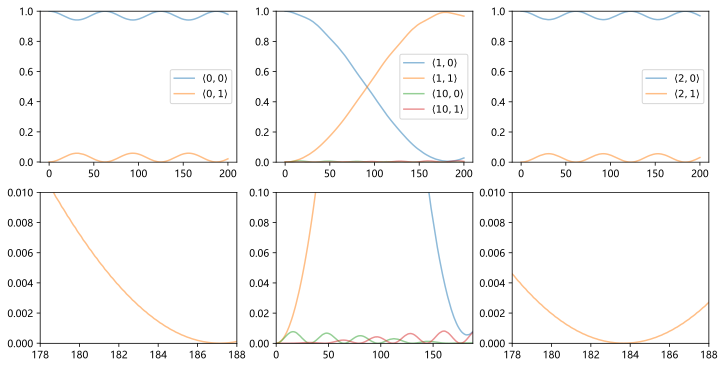

In [12]:


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1)],
                        [(1,0),(1,1),(10,0),(10,1)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            # if (ql,tl) not in [(0,0), (1,1),(2,0)]:
            axes[row, col].plot(tlist,results[col].expect[i],label = rf"$\langle{ql},{tl}\rangle$",alpha=0.5)
            # else:
            #     axes[row, col].plot(tlist,1 - results[col].expect[i],label = rf"1 - $\langle{ql}{tl}\rangle$",alpha=0.5)
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)
axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)
axes[1,0].set_ylim(-1e-5,1e-2)
axes[1,1].set_ylim(-1e-5,1e-1)
axes[1,2].set_ylim(-1e-5,1e-2)

xmin  = 0
xmax = 188
axes[1,0].set_xlim(xmax-10,xmax)
axes[1,1].set_xlim(xmin,xmax)
axes[1,2].set_xlim(xmax-10,xmax)